<a href="https://colab.research.google.com/github/alkhadrifuad/DataScience_250401020114_AlkhadriFuad/blob/master/Pertemua11_alkhadrifuad_250401020114.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#1. Generate & Eksplorasi Dataset

Shape: (300, 4)
       pendapatan_tahunan  skor_belanja    usia
count              300.00        300.00  300.00
mean                84.38         55.45   41.23
std                 38.26         21.36   13.11
min                 20.66          0.52   18.00
25%                 51.08         40.46   30.00
50%                 86.52         55.81   42.00
75%                118.39         69.17   52.00
max                148.71        110.02   64.00


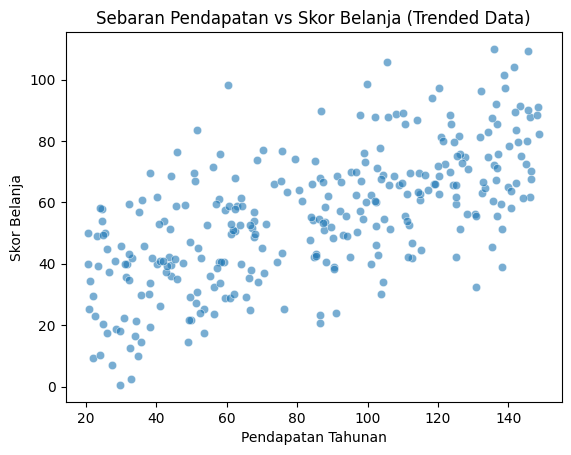

In [2]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns

np.random.seed(42)

# Generate annual income from a uniform distribution
pendapatan_tahunan = np.random.uniform(low=20, high=150, size=300)

# Generate age for customers
usia = np.random.randint(18, 65, size=300)

# Generate spending score with a linear trend based on annual income and a slight influence from age, plus noise
skor_belanja = 0.4 * pendapatan_tahunan + 0.3 * usia + np.random.normal(loc=10, scale=15, size=300)

# Ensure spending score is non-negative
skor_belanja[skor_belanja < 0] = 0

data_dict = {
    'pendapatan_tahunan': pendapatan_tahunan,
    'skor_belanja': skor_belanja,
    'usia': usia
}

df = pd.DataFrame(data_dict)

# Add gender randomly
df['gender'] = np.random.choice(['L', 'P'], len(df))

print('Shape:', df.shape)
print(df.describe().round(2))

sns.scatterplot(data=df, x='pendapatan_tahunan', y='skor_belanja', alpha=0.6)
plt.title('Sebaran Pendapatan vs Skor Belanja (Trended Data)')
plt.xlabel('Pendapatan Tahunan')
plt.ylabel('Skor Belanja')
plt.show()

#2. Preprocessing Data


In [3]:
from sklearn.preprocessing import StandardScaler
X = df[['pendapatan_tahunan', 'skor_belanja']].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print('Rata-rata setelah scaling:', X_scaled.mean(axis=0).round(3))
print('Std setelah scaling :', X_scaled.std(axis=0).round(3))


Rata-rata setelah scaling: [-0.  0.]
Std setelah scaling : [1. 1.]


#3. Metode Elbow untuk Menentukan K

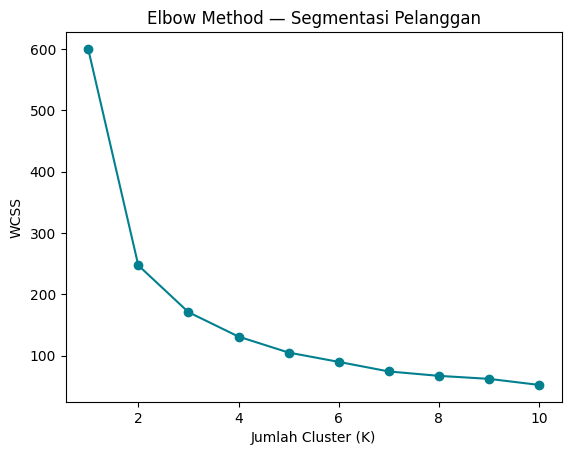

In [4]:
from sklearn.cluster import KMeans

wcss = []

for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42, init='k-means++')
    km.fit(X_scaled)
    wcss.append(km.inertia_)

plt.plot(range(1, 11), wcss, marker='o', color='#028090')
plt.xlabel('Jumlah Cluster (K)')
plt.ylabel('WCSS')
plt.title('Elbow Method — Segmentasi Pelanggan')
plt.show()

Berdasarkan plot "Elbow Method", titik "siku" atau "elbow" yang menandakan jumlah cluster optimal (K) terlihat pada K=3 atau K=4. Pada titik ini, penurunan nilai WCSS (Within-Cluster Sum of Squares) mulai melambat secara signifikan, menunjukkan bahwa penambahan cluster lebih lanjut memberikan sedikit keuntungan.

#4. Melatih Model K-Means

In [5]:
from sklearn.metrics import silhouette_score
model = KMeans(n_clusters=3, random_state=42, init='k-means++')
model.fit(X_scaled)
df['cluster'] = model.labels_
print(f'WCSS akhir : {model.inertia_:.3f}')
print(f'Silhouette Score: {silhouette_score(X_scaled, model.labels_):.3f}')
print(df.groupby('cluster')[['pendapatan_tahunan', 'skor_belanja']].mean().round(2))

WCSS akhir : 170.998
Silhouette Score: 0.393
         pendapatan_tahunan  skor_belanja
cluster                                  
0                    125.70         76.20
1                     42.65         33.18
2                     82.78         55.84


#5. Visualisasi Hasil Clustering

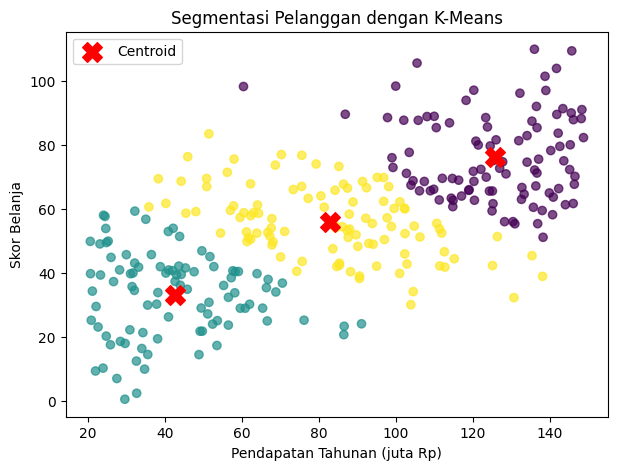

In [6]:
centroids = scaler.inverse_transform(model.cluster_centers_)

plt.figure(figsize=(7, 5))
plt.scatter(
    df['pendapatan_tahunan'],
    df['skor_belanja'],
    c=df['cluster'],
    cmap='viridis',
    alpha=0.7
)

plt.scatter(
    centroids[:, 0],
    centroids[:, 1],
    c='red',
    marker='X',
    s=200,
    label='Centroid'
)

plt.xlabel('Pendapatan Tahunan (juta Rp)')
plt.ylabel('Skor Belanja')
plt.title('Segmentasi Pelanggan dengan K-Means')
plt.legend()
plt.show()

Pada visualisasi hasil clustering ini, kita dapat melihat data pelanggan telah berhasil dibagi menjadi 3 kelompok berbeda berdasarkan 'pendapatan_tahunan' dan 'skor_belanja'. Setiap warna merepresentasikan satu cluster, dan tanda 'X' merah adalah centroid atau pusat dari setiap cluster.

* Cluster Hijau:
 Pelanggan dengan 'pendapatan_tahunan' dan 'skor_belanja' rendah, menunjukkan segmen pelanggan yang hemat atau ekonomis.
* Cluster Kuning:
Pelanggan dengan 'pendapatan_tahunan' dan 'skor_belanja' menengah, mewakili segmen pelanggan rata-rata.
* Cluster Ungu:
Pelanggan dengan 'pendapatan_tahunan' dan 'skor_belanja' tinggi, yang bisa diidentifikasi sebagai segmen pelanggan boros atau bernilai tinggi.

#6. Hierarchical Clustering (Pembanding)

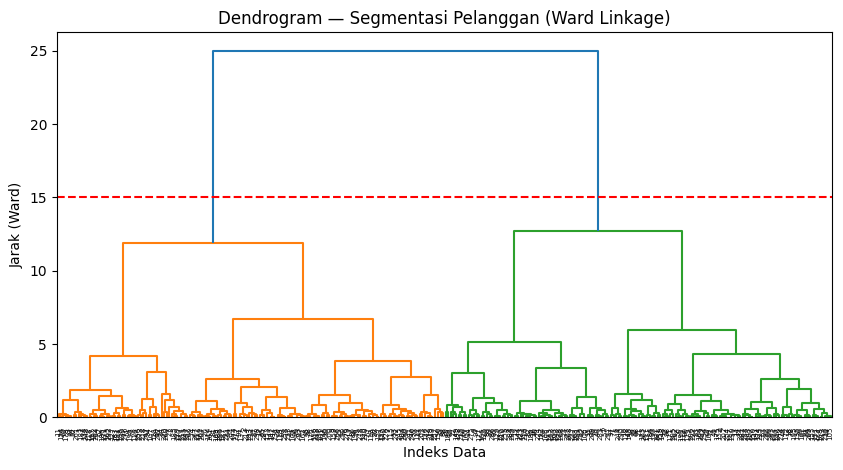

In [7]:
from scipy.cluster.hierarchy import dendrogram, linkage

Z = linkage(X_scaled, method='ward')

plt.figure(figsize=(10, 5))
dendrogram(Z)

plt.title('Dendrogram — Segmentasi Pelanggan (Ward Linkage)')
plt.xlabel('Indeks Data')
plt.ylabel('Jarak (Ward)')

plt.axhline(y=15, color='red', linestyle='--')  # contoh garis potong
plt.show()

Pada dendrogram ini, kita dapat melihat bagaimana setiap data point digabungkan menjadi cluster yang lebih besar. Garis merah putus-putus pada y=15 berfungsi sebagai garis potong.

* Setiap cabang horizontal yang dipotong oleh garis
merah merepresentasikan sebuah cluster.


* Jika kita memotong dendrogram pada ketinggian y=15, kita akan mendapatkan 3 cluster utama, yang ditunjukkan oleh 3 cabang vertikal besar yang melewati garis tersebut. Hal ini sejalan dengan hasil K-Means sebelumnya.